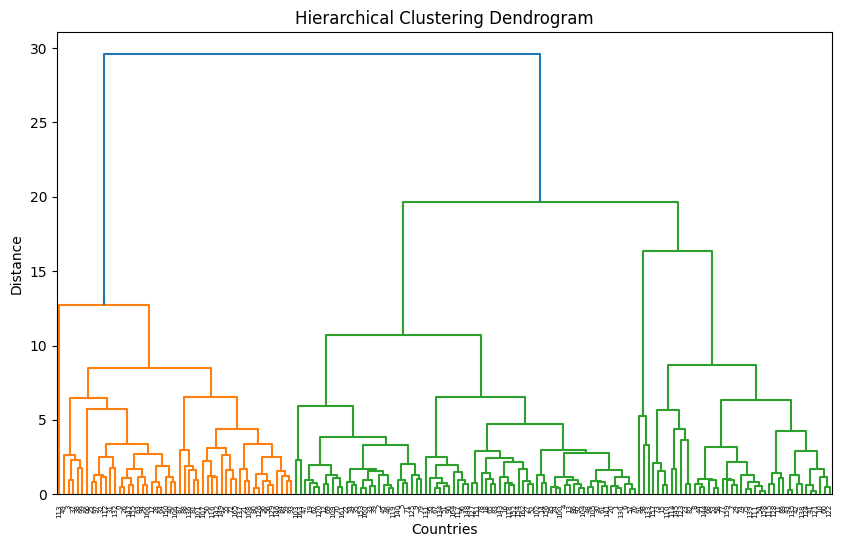


Cluster Mean Values:

         child_mort    exports    imports        income  inflation  \
Cluster                                                              
1         89.296078  28.586647  43.334625   3847.901961  11.668137   
2         21.394595  41.118649  48.185135  11419.189189   7.516122   
3          6.042857  56.297619  48.926190  43378.571429   3.530905   

         life_expec  total_fer          gdpp  
Cluster                                       
1         59.711765   4.882353   1886.823529  
2         72.986486   2.256216   5980.486486  
3         79.440476   1.817857  38719.761905  

Cluster Counts:

Cluster
1    51
2    74
3    42
Name: count, dtype: int64

Silhouette Score: 0.2818870324810932


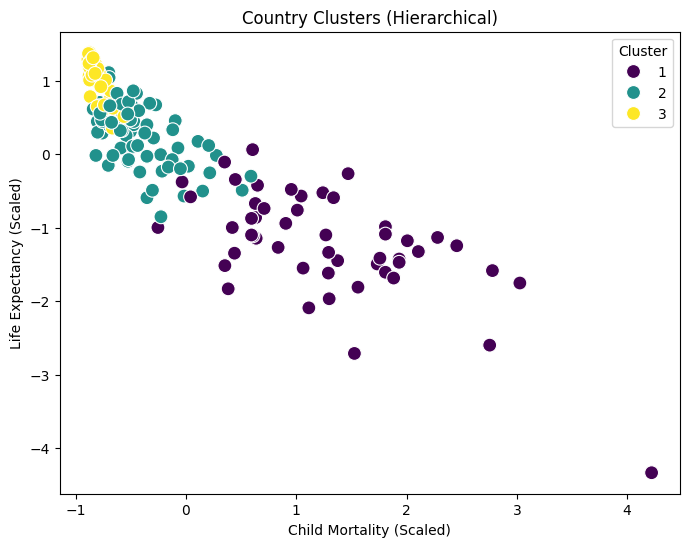

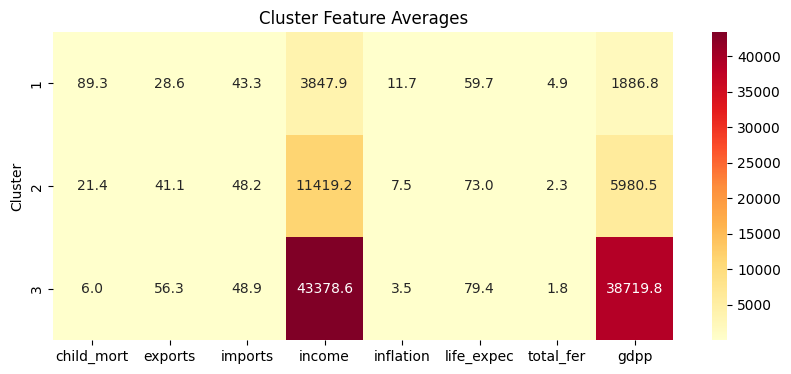

In [1]:
# =========================
# 📦 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score


# =========================
# 📊 2. Load Dataset
# =========================
df = pd.read_csv(r"C:\Users\Azhar computer\Downloads\archive (18)\Country-data.csv")
df = df.dropna()


# =========================
# 🧹 3. Feature Selection
# =========================
features = [
    "child_mort",
    "exports",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "gdpp"
]

X = df[features]


# =========================
# ⚖️ 4. Feature Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 🌳 5. Dendrogram (Hierarchical Clustering)
# =========================
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()


# =========================
# 🔢 6. Create Clusters
# =========================
df["Cluster"] = fcluster(Z, t=3, criterion="maxclust")


# =========================
# 📊 7. Cluster Analysis
# =========================
print("\nCluster Mean Values:\n")
print(df.groupby("Cluster")[features].mean())

print("\nCluster Counts:\n")
print(df["Cluster"].value_counts().sort_index())


# =========================
# 🎯 8. Silhouette Score
# =========================
score = silhouette_score(X_scaled, df["Cluster"])
print("\nSilhouette Score:", score)


# =========================
# 📉 9. Visualization (2D Scatter)
# =========================
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_scaled[:, 0],   # child_mort
    y=X_scaled[:, 5],   # life_expec
    hue=df["Cluster"],
    palette="viridis",
    s=100
)

plt.title("Country Clusters (Hierarchical)")
plt.xlabel("Child Mortality (Scaled)")
plt.ylabel("Life Expectancy (Scaled)")
plt.show()


# =========================
# 🔥 10. Heatmap (Cluster Insights)
# =========================
plt.figure(figsize=(10, 4))

sns.heatmap(
    df.groupby("Cluster")[features].mean(),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Cluster Feature Averages")
plt.show()